In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import math
from importlib import reload

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import mars

import pandas as pd

Some stuff might fail: issue in joblib
[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


In [2]:
dtype = torch.float64
torch.manual_seed(42)
np.random.default_rng(42)

Generator(PCG64) at 0x2209116CD60

In [3]:
def parametrize_stick(s1, s2, s3):
    nx = s1
    ny = (1 - s1) * s2
    nz = (1 - s1) * (1 - s2) * s3
    ns = (1 - s1) * (1 - s2) * (1 - s3)
    return torch.tensor([nx, ny, nz, ns], dtype=dtype)

def get_context(sample, params):
    populations = parametrize_stick(params["s1"], params["s2"], params["s3"])
    return mars.population.Context(basis="zfs", sample=sample, dtype=dtype, init_populations=populations)

def get_sample(params):
    g_mean, g_delta, J, D, E, lorentz, gauss =\
        params["g_mean"], params["g_delta"], params["J"], params["D"], params["E"], params["lorentz"], params["gauss"]
    
    g_strain = [params["g1_strain"], params["g2_strain"], params["g2_strain"]]
    
    g1 = mars.spin_model.Interaction(g_mean + g_delta / 2, dtype=dtype, strain=g_strain)
    g2 = mars.spin_model.Interaction(g_mean - g_delta / 2, dtype=dtype, strain=g_strain)
    DE = mars.spin_model.Interaction(-2*J, dtype=dtype) + mars.spin_model.DEInteraction([D, E], dtype=dtype)
    
    spin_system = mars.spin_model.SpinSystem(electrons=[0.5, 0.5], g_tensors=[g1, g2], electron_electron=[(0, 1, DE)], dtype=dtype)
    sample = mars.spin_model.MultiOrientedSample(base_spin_system=spin_system, gauss=gauss, lorentz=lorentz, dtype=dtype)
    
    return sample, get_context(sample, params)

In [4]:
print(
    parametrize_stick(0.2, 0.2, 0.3)
)

tensor([0.2000, 0.1600, 0.1920, 0.4480], dtype=torch.float64)


In [5]:
master_params = {
"g_mean": 2.002,
"g_delta": 0.004,
"J": 1e6 * 100,
"D": 1e6 * 300,
"E": 1e6 * 40,
    
"g1_strain": 0.000,
"g2_strain": 0.000,
"g3_strain": 0.003,

"lorentz": 5e-4,
"gauss": 1e-4,
    
"s1": 0.2,
"s2": 0.2,
"s3": 0.3,
}

In [6]:
sample, context = get_sample(master_params)

staionary = mars.spectra_manager.StationarySpectra(
    freq=9.8*1e9, sample=sample, harmonic=0, context=context, temperature=200.0, dtype=dtype)
fields = torch.linspace(0.33, 0.37, 500, dtype=dtype)
master_out = staionary(fields=fields, sample=sample)


In [7]:
master_out = staionary(fields=fields, sample=sample)

def add_noise(out, fields):
    max_level = out.abs().max()
    epsilon = torch.randn_like(out) * 0.01 * max_level
    return out + epsilon

def add_distortion(out, fields):
    max_level = out.abs().max()
    X = (fields - fields[0]) / (fields[-1] - fields[0]) 
    factor = max_level * 0.05
    
    C0 = factor * 0.0
    C1 = factor * (X - factor) * 0.0
    C2 = factor * (X ** 2)
    baseline = C0 + C1 + C2
    return add_noise(out + baseline, fields)

master_out = add_distortion(master_out, fields)

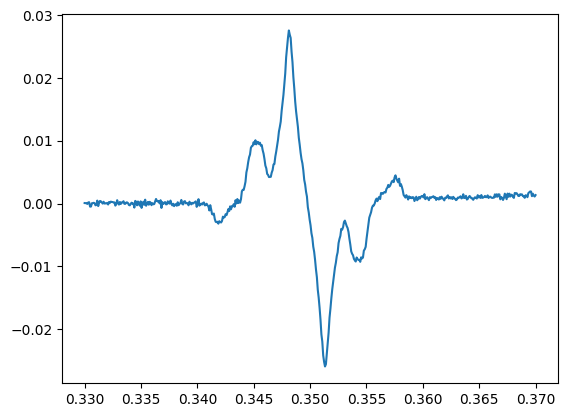

In [8]:
plt.plot(fields.numpy(), master_out.numpy())

In [9]:
class Simulator():
    def __init__(self):
        self.fixed_params = {"g1_strain": 0.0, "g2_strain": 0.0, "g3_strain": 0.0}
        pass
        
    def __call__(self, fields, params):
        full_params = {}
        full_params.update(params)
        full_params.update(self.fixed_params)
        
        sample, context = get_sample(full_params)
        staionary = mars.spectra_manager.StationarySpectra(
            freq=9.8*1e9, sample=sample, harmonic=0, context=context, temperature=200.0, dtype=dtype)
        out = staionary(fields=fields, sample=sample)
        
        return out

In [10]:
sample.mesh.rotation_matrices.dtype

torch.float64

In [13]:
master_params = {
"g_mean": 2.002,
"g_delta": 0.004,
"J": 1e6 * 100,
"D": 1e6 * 300,
"E": 1e6 * 40,
    
"g1_strain": 0.000,
"g2_strain": 0.000,
"g3_strain": 0.003,

"lorentz": 5e-4,
"gauss": 1e-4,
    
"s1": 0.2,
"s2": 0.2,
"s3": 0.3,
}

from mars.optimization import ParamSpec, ParameterSpace


param_space = ParameterSpace(
    specs=[
        ParamSpec(name="g_mean", bounds=(2.0015, 2.0025), default=2.0025),
        ParamSpec(name="g_delta", bounds=(0.00, 0.008), default=0.00),
        ParamSpec(name="J", bounds=(10*1e6, 250*1e6), default=10*1e6),
        ParamSpec(name="D", bounds=(200 * 1e6, 400 * 1e6), default=200 * 1e6),
        ParamSpec(name="E", bounds=(0 * 1e6, 60 * 1e6), default=0 * 1e6),
        ParamSpec(name="lorentz", bounds=(1e-4, 5e-4), default=1e-4),
        ParamSpec(name="gauss", bounds=(1e-4, 5e-4), default=1e-4),
        ParamSpec(name="s1", bounds=(0.15, 0.4), default=0.15),
        ParamSpec(name="s2", bounds=(0.15, 0.4), default=0.15),
        ParamSpec(name="s3", bounds=(0.2, 0.4), default=0.2),
    ]
)
"""
param_space = ParameterSpace(
    specs=[
        mars.optimization.ParamSpec(name="g_mean", bounds=(2.0015, 2.0025), default=2.0025),
        mars.optimization.ParamSpec(name="g_delta", bounds=(0.00, 0.008), default=0.00),
        mars.optimization.ParamSpec(name="J", bounds=(10*1e6, 250*1e6), default=10*1e6),
        mars.optimization.ParamSpec(name="D", bounds=(200 * 1e6, 400 * 1e6), default=200 * 1e6),
        mars.optimization.ParamSpec(name="E", bounds=(0 * 1e6, 60 * 1e6), default=0 * 1e6),
        mars.optimization.ParamSpec(name="lorentz", bounds=(1e-4, 1e-3), default=1e-4),
        mars.optimization.ParamSpec(name="gauss", bounds=(1e-4, 2e-3), default=1e-4),
        mars.optimization.ParamSpec(name="s1", bounds=(0.0, 1.0), default=1e-4),
        mars.optimization.ParamSpec(name="s2", bounds=(0.0, 1.0), default=1e-4),
        mars.optimization.ParamSpec(name="s3", bounds=(0.0, 1.0), default=1e-4),
    ],
)
"""

'\nparam_space = ParameterSpace(\n    specs=[\n        mars.optimization.ParamSpec(name="g_mean", bounds=(2.0015, 2.0025), default=2.0025),\n        mars.optimization.ParamSpec(name="g_delta", bounds=(0.00, 0.008), default=0.00),\n        mars.optimization.ParamSpec(name="J", bounds=(10*1e6, 250*1e6), default=10*1e6),\n        mars.optimization.ParamSpec(name="D", bounds=(200 * 1e6, 400 * 1e6), default=200 * 1e6),\n        mars.optimization.ParamSpec(name="E", bounds=(0 * 1e6, 60 * 1e6), default=0 * 1e6),\n        mars.optimization.ParamSpec(name="lorentz", bounds=(1e-4, 1e-3), default=1e-4),\n        mars.optimization.ParamSpec(name="gauss", bounds=(1e-4, 2e-3), default=1e-4),\n        mars.optimization.ParamSpec(name="s1", bounds=(0.0, 1.0), default=1e-4),\n        mars.optimization.ParamSpec(name="s2", bounds=(0.0, 1.0), default=1e-4),\n        mars.optimization.ParamSpec(name="s3", bounds=(0.0, 1.0), default=1e-4),\n    ],\n)\n'

In [12]:
from mars.optimization import ParamSpec, ParameterSpace, SpectrumFitter

specs = [
    ParamSpec(name="g_mean", bounds=(2.0015, 2.0025), default=2.0025),
    ParamSpec(name="g_delta", bounds=(0.00, 0.008), default=0.00),
    ParamSpec(name="J", bounds=(10 * 1e6, 250 * 1e6), default=10 * 1e6),
    ParamSpec(name="D", bounds=(200 * 1e6, 400 * 1e6), default=200 * 1e6),
    ParamSpec(name="E", bounds=(0 * 1e6, 60 * 1e6), default=0 * 1e6),
    ParamSpec(name="lorentz", bounds=(1e-4, 5e-4), default=1e-4),
    ParamSpec(name="gauss", bounds=(1e-4, 5e-4), default=1e-4),
    ParamSpec(name="s1", bounds=(0.0, 1.0), default=0.15),
    ParamSpec(name="s2", bounds=(0.0, 1.0), default=0.15),
    ParamSpec(name="s3", bounds=(0.0, 1.0), default=0.2),
]
param_space = ParameterSpace(specs)


param_space = ParameterSpace(
    specs=[
        ParamSpec(name="g_mean", bounds=(2.0015, 2.0025), default=2.0025),
        ParamSpec(name="g_delta", bounds=(0.00, 0.008), default=0.00),
        ParamSpec(name="J", bounds=(10 * 1e6, 250 * 1e6), default=10 * 1e6),
        ParamSpec(name="D", bounds=(200 * 1e6, 400 * 1e6), default=200 * 1e6),
        ParamSpec(name="E", bounds=(0 * 1e6, 60 * 1e6), default=0 * 1e6),
        ParamSpec(name="lorentz", bounds=(1e-4, 5e-4), default=1e-4),
        ParamSpec(name="gauss", bounds=(1e-4, 5e-4), default=1e-4),
        ParamSpec(name="s1", bounds=(0.0, 1.0), default=0.15),
        ParamSpec(name="s2", bounds=(0.0, 1.0), default=0.15),
        ParamSpec(name="s3", bounds=(0.0, 1.0), default=0.2),
    ]
)


res_coblya = fitter.fit(
    backend="ng", optimizer="Cobyla", budget=1000)

res_penalty = fitter.fit(
    backend="ng", optimizer="Cobyla", budget=1000,
    use_penalty=True, penalty_names=["J", "g_delta"])

res_TPE = fitter.fit(
    backend="optuna", n_trials=1000)

sampler = optuna.samplers.CmaEsSampler()
res_cmaes = optimizer.fit(
    backend="optuna", n_trials=1000, sampler=sampler)


In [14]:
optimizer = mars.optimization.SpectrumFitter(
    x_exp = fields, y_exp=master_out,
    param_space=param_space, spectra_simulator=Simulator(),
)

D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\optimization\fitter.py:1720: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_exp = torch.tensor(x_exp, dtype=dtype, device=device)
D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\optimization\fitter.py:1721: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_exp = torch.tensor(y_exp, dtype=dtype, device=device)


In [ ]:
out_coblya = optimizer.fit(backend="ng", optimizer="Cobyla", budget=1000)

In [ ]:
out_coblya_penalty = optimizer.fit(backend="ng", optimizer="Cobyla", budget=1000, use_penalty=True, penalty_names=["J", "g_delta"], update_penalty_every=40, restart_every=80)

In [17]:
out_TPE = optimizer.fit(backend="optuna", n_trials=1000, use_penalty=False, penalty_names=["J", "g_delta"])

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  0%|          | 0/1000 [00:00<?, ?it/s]

Bottle v0.13.4 server starting up (using WSGIRefServer())...
Listening on http://localhost:8080/
Hit Ctrl-C to quit.



In [15]:
out_TPE_penalty = optimizer.fit(backend="optuna", n_trials=500, use_penalty=True, penalty_names=["J", "g_delta"], update_penalty_every=30, restart_every=60)

In [18]:
sampler = optuna.samplers.CmaEsSampler()
out_TPE_penalty = optimizer.fit(backend="optuna", n_trials=500, use_penalty=True, penalty_names=["J", "g_delta"], update_penalty_every=30, restart_every=60)

NameError: name 'optuna' is not defined

In [19]:
import optuna

sampler = optuna.samplers.CmaEsSampler()
out_cmaes = optimizer.fit(backend="optuna", n_trials=1000, sampler=sampler, update_penalty_every=30, restart_every=60)

  0%|          | 0/1000 [00:00<?, ?it/s]

Bottle v0.13.4 server starting up (using WSGIRefServer())...
Listening on http://localhost:8080/
Hit Ctrl-C to quit.



# Solutions

Clean TPE

Clean Coblya

TPE with penalty

Coblya with penalty

In [27]:
out_coblya.best_loss

tensor(0.0591, dtype=torch.float64)

D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\optimization\searcher.py:405: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


[<Figure size 600x500 with 2 Axes>]

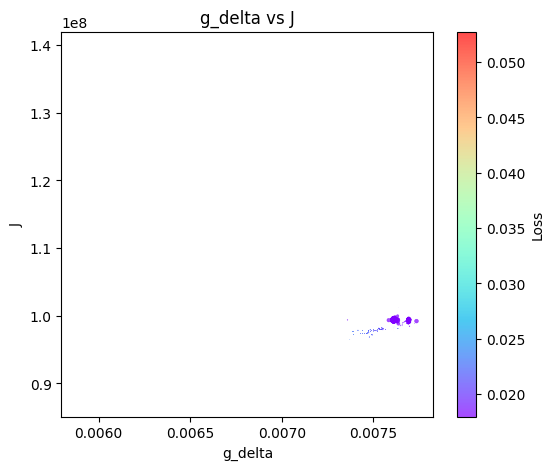

In [20]:
seacrher = mars.optimization.SpaceSearcher(loss_rel_tol=2.0, k_neighbors=0)
#seacrher.plot_2d_pairs(fit_result=out_coblya_penalty, param_names=["g_delta", "J"])
seacrher.plot_2d_pairs(fit_result=out_coblya, param_names=["g_delta", "J"])

In [21]:
import typing as tp

def extract_trials_from_fit(fit_result,
                               param_names: tp.Optional[list[str]] = None):
    """
    Return arrays: (param_matrix, losses, trial_indices).

    param_matrix shape: (n_trials, n_varying_params)
    losses: array of length n_trials (float)
    trial_indices: list of optuna trial numbers corresponding to rows
    """
    backend = fit_result.optimizer_info["backend"]
    opt_info = fit_result.optimizer_info

    if backend == "nevergrad":
        trials = opt_info.get("trials", [])
    elif backend == "optuna":
        if "study" in opt_info:
            trials = [t for t in opt_info["study"].trials if t.state.is_finished()]
        elif "trials" in opt_info:
            trials = [t for t in opt_info["trials"] if t.get("state") == "COMPLETE"]
        else:
            trials = []
    else:
        raise KeyError(f"Unknown backend: {backend}")

    if len(trials) == 0:
        return np.zeros((0, 0)), np.array([]), []

    if param_names is None:
        first = trials[0]
        p_dict = first.params if hasattr(first, "params") else first.get("params", {})
        param_names = list(p_dict.keys())
    return trials, param_names


def parse_trials(trials, param_names: list[str]):
    param_rows = []
    losses = []
    trial_ids = []
    for t in trials:
        if t.value is None:
            continue
        vals = []
        for name in param_names:
            if name not in t.params:
                vals = None
                break
            vals.append(float(t.params[name]))
        if vals is None:
            continue
        param_rows.append(vals)
        losses.append(float(t.value))
        trial_ids.append(t._trial_id)
    if len(param_rows) == 0:
        return np.zeros((0, 0)), np.array([]), []
    P = np.asarray(param_rows, dtype=float)
    L = np.asarray(losses, dtype=float)
    return P, L, np.asarray(trial_ids, dtype=np.int32)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


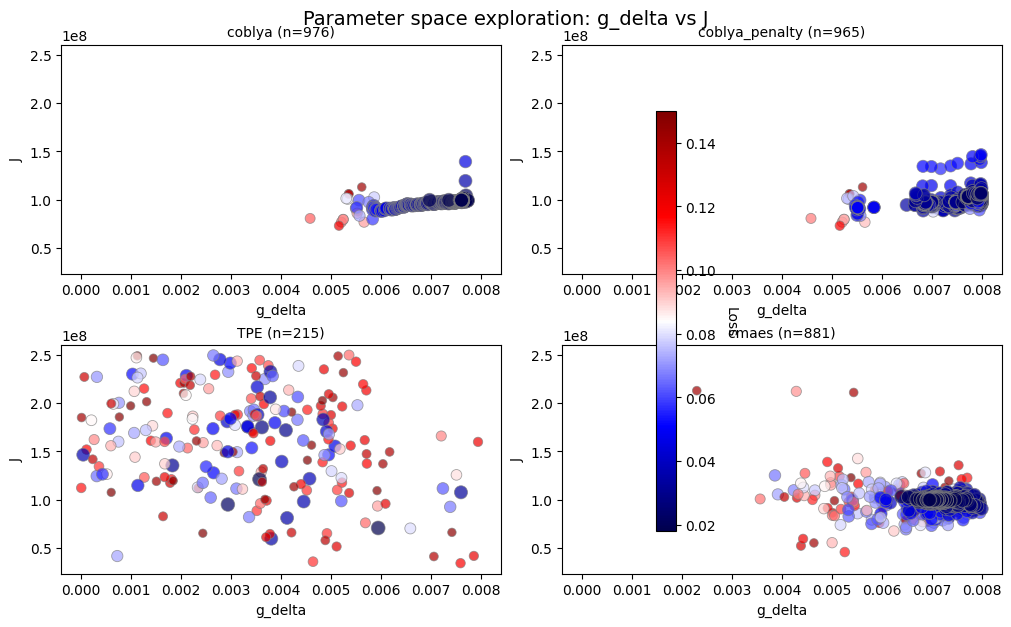

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Configuration ---
results = [out_coblya, out_coblya_penalty, out_TPE, out_cmaes]
names = ["coblya", "coblya_penalty", "TPE", "cmaes"]  # fixed typo: "coblye" → "coblya"
param_names = ["g_delta", "J"]
loss_min, loss_max = 0.0, 0.15  # filter range
cmap = "seismic"
figsize = (10, 6)

# --- Step 1: Collect filtered data + compute GLOBAL axis limits ---
all_P = []
all_L = []
processed = []  # store (P_filt, L_filt, best_loss) per result

for res in results:
    trials, pnames = extract_trials_from_fit(res, param_names)
    P, L, _ = parse_trials(trials, pnames)
    
    # Filter by loss
    mask = (L >= loss_min) & (L <= loss_max)
    P_filt, L_filt = P[mask], L[mask]
    
    if P_filt.size > 0:
        all_P.append(P_filt)
        all_L.append(L_filt)
        processed.append((P_filt, L_filt, float(L_filt.min())))

# Compute global bounds for consistent axes
if all_P:
    all_P_concat = np.vstack(all_P)
    x_min, x_max = all_P_concat[:, 0].min(), all_P_concat[:, 0].max()
    y_min, y_max = all_P_concat[:, 1].min(), all_P_concat[:, 1].max()
    
    # Add small padding (5%)
    x_pad = 0.05 * (x_max - x_min) or 0.01
    y_pad = 0.05 * (y_max - y_min) or 0.01
    xlim = (x_min - x_pad, x_max + x_pad)
    ylim = (y_min - y_pad, y_max + y_pad)
else:
    xlim, ylim = (0, 1), (0, 1)  # fallback

# Optional: global color scale (use global min loss for consistent weighting)
global_best = min(item[2] for item in processed) if processed else 0.0

# --- Step 2: Plot ---
fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
axes = axes.flatten()

for idx, (P_filt, L_filt, best_loss) in enumerate(processed):
    ax = axes[idx]
    
    # Compute weights conceptually: lower loss → larger marker
    weights = np.exp(-(L_filt - best_loss) / (L_filt.max() - best_loss + 1e-8))
    sizes = 100 * weights / weights.max()
    
    sc = ax.scatter(
        P_filt[:, 0], P_filt[:, 1],
        c=L_filt,
        s=sizes,
        cmap=cmap,
        alpha=0.7,
        linewidth=0.6,
        edgecolors='gray'
    )
    
    # Consistent axes
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(param_names[0])
    ax.set_ylabel(param_names[1])
    ax.set_title(f"{names[idx]} (n={len(P_filt)})", fontsize=10)

# Hide unused subplots (if <4 results passed filter)
for idx in range(len(processed), 4):
    axes[idx].set_visible(False)

# Shared colorbar
cbar_ax = fig.add_axes([0.65, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
norm = Normalize(vmin=min(L.min() for L in all_L), vmax=max(L.max() for L in all_L))
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Loss", rotation=270, labelpad=15)

fig.suptitle("Parameter space exploration: g_delta vs J", fontsize=14, y=1.02)
plt.savefig("optimization_res_2.eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


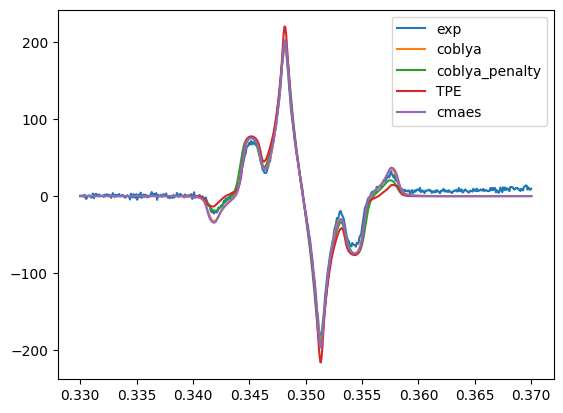

In [43]:
x = optimizer.x_exp

plt.plot(x, optimizer.y_exp, label="exp")
for res, name in zip(results, names):
    plt.plot(x, res.best_spectrum, label=name)
plt.legend()
plt.savefig("spectra.eps")

In [195]:
analyzer = mars.optimization.UncertaintyAnalyzer(optimizer, out, method="bootstrap")

In [ ]:
uncertanity_res = analyzer(param_names=["g_delta"])

In [194]:
uncertanity_res

UncertaintyResult  method='mcmc'  confidence_level=95%
------------------------------------------------------------
  g_delta  0.00593795  [0.00550099, 0.00796442]  (±0.00123171)

In [30]:
searc_res = seacrher(out, param_names = ["J", "g_delta"])

In [ ]:
seacrher.cluster_trials(out)

D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\optimization\searcher.py:499: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


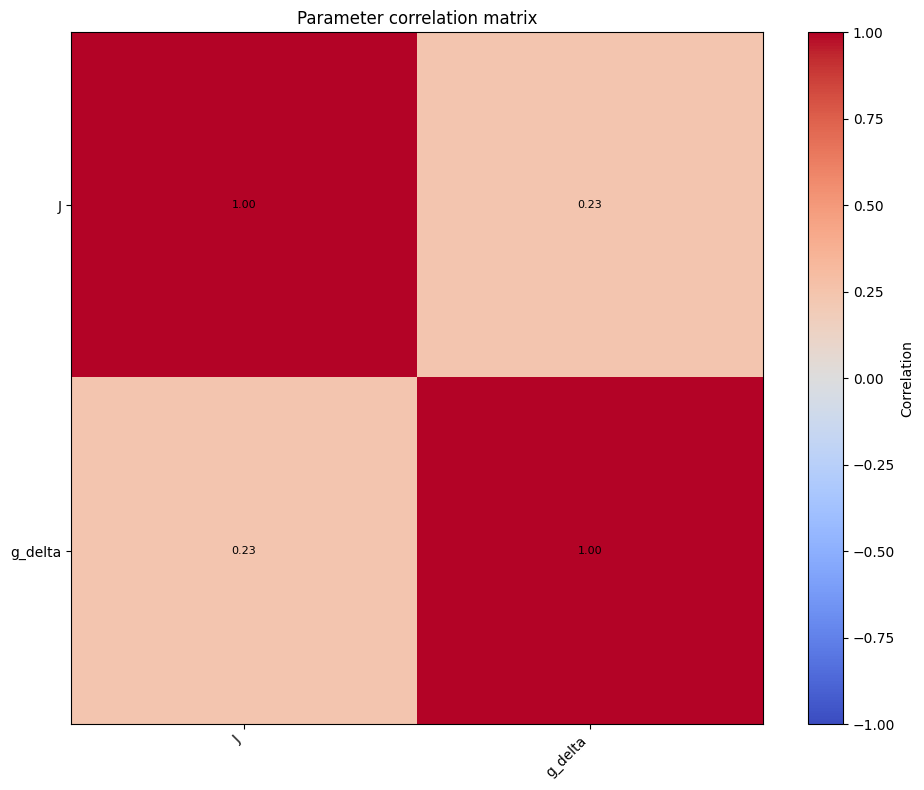

In [32]:
param_names = ["J", "g_delta"]
figs = seacrher.plot_correlation_matrix(out, param_names=param_names)

In [1]:
fixed_params = out_cmaes.best_params.copy()

param_space_master = ParameterSpace(
    specs=[],
    fixed_params=fixed_params
)

NameError: name 'out_cmaes' is not defined

In [38]:
optimizer._loss_from_params(param_space_master)

tensor(0.0570, dtype=torch.float64)

In [39]:
out_cmaes.best_params

{'g_mean': 2.0020997388851076,
 'g_delta': 0.005012195600042161,
 'J': 90851945.86290072,
 'D': 302422057.1146653,
 'E': 42260804.68539222,
 'lorentz': 0.0006221773793205186,
 'gauss': 0.0003124348761429792,
 's1': 0.267570299397179,
 's2': 0.21778049626504012,
 's3': 0.42600412439145174}

In [68]:
master_params

{'g_mean': 2.002,
 'g_delta': 0.004,
 'J': 100000000.0,
 'D': 300000000.0,
 'E': 40000000.0,
 'g1_strain': 0.0,
 'g2_strain': 0.0,
 'g3_strain': 0.003,
 'lorentz': 0.0005,
 'gauss': 0.0001,
 's1': 0.2,
 's2': 0.2,
 's3': 0.3}